In [ ]:
'''
For the analysis, I'm going to download some libraries for plots and also for reading the dataframe
'''
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cefr_to_int_mapping = {"A2": 1, "B1": 2, "B2": 3, "C1": 4}

df_normistral = pd.read_parquet("/content/drive/MyDrive/normistral_rq2_full_final.parquet")

print(f"Loaded: {len(df_normistral):,} rows")

Loaded: 1,764,392 rows


In [ ]:
'''
Step 2 (Normistral): Add base prediction and comparison columns

This step prepares the dataframe for counterfactual fairness analysis by:
  (1) diagnosing where unparsed predictions occur and whether they introduce
      selection bias on demographic dimensions,
  (2) filtering out essays with unparsed base predictions and individual
      variant rows with unparsed predictions,
  (3) extracting each retained essay's base prediction,
  (4) attaching it to every variant row, and
  (5) computing two key columns: changed_vs_base (binary) and D_i (signed difference).

Encoding (unified across all models): A2=1, B1=2, B2=3, C1=4.

Unlike EuroLLM and Llama (which produce predictions only in the B1/B2 subspace
in practice), Normistral predicts across the full A2-C1 range, so D_i can take
values in {-3, -2, -1, 0, +1, +2, +3}.

Methodological note for the thesis:
  Normistral occasionally produces output that cannot be parsed to a valid
  CEFR label. This step tracks both the scope of the loss and its distribution
  across demographic values, providing the basis for transparent reporting in
  the methodology limitations section.
'''

print("=" * 70)
print("NORMISTRAL - STEP 2: ATTACHING BASE PREDICTIONS AND COMPUTING DIFFERENCES")
print("=" * 70)

# ---------------------------------------------------------------
# 2.0 Diagnostic: where are the unparsed predictions?
# ---------------------------------------------------------------
# Before filtering, characterize the scope and location of unparsed predictions.
# This tells us:
#   (a) total essays in the raw dataframe
#   (b) which essays have an unparsed BASE prediction (these will be fully dropped)
#   (c) which essays have unparsed VARIANT predictions only (partial loss within
#       an essay - the essay is retained but with fewer variants)
#   (d) the demographic distribution of unparsed rows (selection bias check)

print(f"\n[2.0 DIAGNOSTIC] Characterizing unparsed predictions")
print(f"      Raw dataframe size: {len(df_normistral):,} rows")
print(f"      Distinct essays in raw dataframe: {df_normistral['essay_id'].nunique()}")

unparsed_mask = df_normistral["pred_label"].isna() | df_normistral["pred_int"].isna()
n_unparsed = unparsed_mask.sum()
print(f"      Rows with unparsed predictions: {n_unparsed:,} "
      f"({100*n_unparsed/len(df_normistral):.2f}% of all rows)")

# Breakdown by variant_type
unparsed_by_type = df_normistral[unparsed_mask]["variant_type"].value_counts()
print(f"\n      Unparsed rows broken down by variant_type:")
for vt, count in unparsed_by_type.items():
    print(f"        {vt}: {count:,}")

# Essays with unparsed base predictions (these will be entirely dropped)
unparsed_base_essays = (
    df_normistral[(df_normistral["variant_type"] == "base") & unparsed_mask]
    ["essay_id"].unique()
)
print(f"\n      Essays with unparsed BASE predictions: {len(unparsed_base_essays)}")
print(f"      (these essays will be entirely excluded from the analysis)")
if len(unparsed_base_essays) > 0:
    sorted_ids = sorted(unparsed_base_essays.tolist())
    print(f"      Essay IDs of dropped essays:")
    print(f"        {sorted_ids[:20]}"
          + (" ..." if len(sorted_ids) > 20 else ""))

# Essays with valid base but some unparsed variants (partial loss)
essays_with_valid_base_set = set(
    df_normistral[(df_normistral["variant_type"] == "base") & ~unparsed_mask]
    ["essay_id"].unique()
)
essays_with_partial_loss = [
    e for e in df_normistral[(df_normistral["variant_type"] == "variant") & unparsed_mask]
    ["essay_id"].unique()
    if e in essays_with_valid_base_set
]
print(f"\n      Essays with valid base but at least one unparsed variant: "
      f"{len(essays_with_partial_loss)}")
print(f"      (these essays are kept but with reduced variant counts)")

# Distribution of unparsed variants per affected essay
if len(essays_with_partial_loss) > 0:
    unparsed_per_essay = (
        df_normistral[unparsed_mask
                      & (df_normistral["variant_type"] == "variant")
                      & df_normistral["essay_id"].isin(essays_with_partial_loss)]
        .groupby("essay_id").size()
    )
    print(f"      Distribution of unparsed variants per affected essay:")
    print(f"        Mean:   {unparsed_per_essay.mean():.1f}")
    print(f"        Median: {unparsed_per_essay.median():.0f}")
    print(f"        Min:    {unparsed_per_essay.min()}")
    print(f"        Max:    {unparsed_per_essay.max()}")
    print(f"        (out of approximately 2,744 designed variants per essay)")

# Selection bias check across demographic values
print(f"\n      Selection bias check: unparse rate by demographic value")
print(f"      (rates should be approximately equal across values within each variable;")
print(f"       systematic differences would indicate bias in which demographics the")
print(f"       model fails to predict on)")
demographic_vars = ["gender", "age_group", "country_ssb_region", "language", "occupation_ssb_group"]
for var in demographic_vars:
    if var not in df_normistral.columns:
        continue
    var_df = df_normistral[df_normistral["variant_type"] == "variant"]
    rates = (
        var_df.assign(_unparsed=var_df["pred_label"].isna() | var_df["pred_int"].isna())
        .groupby(var)["_unparsed"].mean()
        .sort_values(ascending=False)
    )
    if rates.max() - rates.min() > 0.005:
        print(f"\n        {var}:")
        for val, rate in rates.items():
            print(f"          {str(val)[:30]:30s}  {100*rate:.2f}% unparsed")
    else:
        print(f"        {var:30s} uniform unparse rate ~{100*rates.mean():.2f}% (no selection bias)")

print(f"\n[2.0 END DIAGNOSTIC]")
print(f"      Summary: {len(unparsed_base_essays)} essay(s) will be dropped due to unparsed base.")
print(f"               {len(essays_with_partial_loss)} essay(s) retained with reduced variant counts.")

# ---------------------------------------------------------------
# 2.1 Filter out unparsed predictions
# ---------------------------------------------------------------
# Two-stage filter:
#   Stage A: drop entire essays whose base prediction failed to parse. An
#            essay without a valid base has no reference for comparison, so
#            all its variants become unusable.
#   Stage B: among remaining essays, drop individual variant rows where the
#            variant prediction itself failed to parse.

print(f"\n[2.1] Applying filters")

n_total_before = len(df_normistral)
n_essays_total = df_normistral["essay_id"].nunique()

# Stage A: keep only essays with a valid base prediction
essays_with_valid_base = (
    df_normistral[(df_normistral["variant_type"] == "base")
                  & df_normistral["pred_label"].notna()
                  & df_normistral["pred_int"].notna()]
    ["essay_id"].unique()
)
n_essays_with_base = len(essays_with_valid_base)
df_normistral = df_normistral[df_normistral["essay_id"].isin(essays_with_valid_base)].copy()

print(f"      Stage A: dropping essays with unparsed base predictions")
print(f"        Essays before: {n_essays_total}")
print(f"        Essays after:  {n_essays_with_base}")
print(f"        Dropped:       {n_essays_total - n_essays_with_base}")

# Stage B: drop individual unparsed variant rows
n_before_variant_filter = len(df_normistral)
df_normistral = df_normistral[df_normistral["pred_label"].notna()
                              & df_normistral["pred_int"].notna()].copy()
n_after_variant_filter = len(df_normistral)
n_unparsed_variants = n_before_variant_filter - n_after_variant_filter

print(f"      Stage B: dropping individual unparsed variants from retained essays")
print(f"        Variant rows dropped: {n_unparsed_variants:,}")

print(f"      Total rows after filtering: {len(df_normistral):,} "
      f"({100*len(df_normistral)/n_total_before:.1f}% of original)")

# ---------------------------------------------------------------
# 2.2 Extract base predictions for retained essays
# ---------------------------------------------------------------

base_preds_normistral = (
    df_normistral[df_normistral["variant_type"] == "base"]
    [["essay_id", "pred_label", "pred_int"]]
    .rename(columns={"pred_label": "base_label", "pred_int": "base_int"})
)

expected_n = df_normistral["essay_id"].nunique()
print(f"\n[2.2] Extracting base predictions")
print(f"      Base predictions found: {len(base_preds_normistral)}")
print(f"      Expected (one per retained essay): {expected_n}")

if len(base_preds_normistral) != expected_n:
    missing = expected_n - len(base_preds_normistral)
    print(f"      WARNING: {missing} essay(s) still missing a base prediction.")
else:
    print(f"      All retained essays have a base prediction.")

# ---------------------------------------------------------------
# 2.3 Merge base predictions onto all rows
# ---------------------------------------------------------------

df_normistral = df_normistral.merge(base_preds_normistral, on="essay_id", how="left")
print(f"\n[2.3] Merging base predictions onto all rows")
print(f"      Total rows after merge: {len(df_normistral):,}")

# ---------------------------------------------------------------
# 2.4 Compute changed_vs_base
# ---------------------------------------------------------------
# Binary indicator: True if the variant's prediction differs from the base
# prediction for that essay. Equation 4 of the methodology.

df_normistral["changed_vs_base"] = (
    df_normistral["pred_label"] != df_normistral["base_label"]
)

# ---------------------------------------------------------------
# 2.5 Compute D_i (signed prediction difference)
# ---------------------------------------------------------------
# Encoding: A2=1, B1=2, B2=3, C1=4.
# D_i = pred_int (variant) - base_int.
# For Normistral, D_i can range from -3 (e.g. C1 -> A2) to +3 (e.g. A2 -> C1).
# Sign convention:
#   D_i > 0: upgrade (variant predicts a higher CEFR level than base)
#   D_i = 0: variant agrees with base
#   D_i < 0: downgrade (variant predicts a lower CEFR level than base)
# The magnitude indicates how many CEFR levels the prediction shifted.

df_normistral["D_i"] = df_normistral["pred_int"] - df_normistral["base_int"]

# ---------------------------------------------------------------
# 2.6 Sanity checks
# ---------------------------------------------------------------

print(f"\n[2.6] Running sanity checks")

mask_var = df_normistral["variant_type"] == "variant"

check1 = (df_normistral.loc[mask_var, "changed_vs_base"]
          == (df_normistral.loc[mask_var, "D_i"] != 0)).all()
assert check1, "Mismatch between changed_vs_base and D_i != 0"
print(f"      Check 1 passed: changed_vs_base equals (D_i != 0) for all variants")

check2 = (df_normistral.loc[~mask_var, "D_i"] == 0).all()
assert check2, "Base rows should have D_i = 0"
print(f"      Check 2 passed: all base rows have D_i = 0")

# ---------------------------------------------------------------
# 2.7 Summary statistics
# ---------------------------------------------------------------

df_var_normistral = df_normistral[mask_var]
overall_cr = df_var_normistral["changed_vs_base"].mean()

print(f"\n[2.7] Summary of the prepared dataset")
print(f"      Retained essays: {expected_n}")
print(f"      Total variant rows: {len(df_var_normistral):,}")
print(f"      Variants where prediction differs from base: "
      f"{int(df_var_normistral['changed_vs_base'].sum()):,}")
print(f"      Overall change rate: {overall_cr:.4f} ({100*overall_cr:.2f}%)")
print(f"      (proportion of variants where prediction shifts away from base)")

# Per-essay variant counts (post-filtering)
# Important for downstream analysis: essays with very low variant counts
# produce noisier per-essay statistics.
variants_per_essay = df_var_normistral.groupby("essay_id").size()
print(f"\n      Per-essay variant counts (post-filter):")
print(f"        Mean:   {variants_per_essay.mean():.0f}")
print(f"        Median: {variants_per_essay.median():.0f}")
print(f"        Min:    {variants_per_essay.min()}")
print(f"        Max:    {variants_per_essay.max()}")
n_reduced = (variants_per_essay < 2744).sum()
print(f"      Essays with reduced variant counts (<2744): "
      f"{n_reduced} of {len(variants_per_essay)}")
n_severely_reduced = (variants_per_essay < 1500).sum()
if n_severely_reduced > 0:
    print(f"      Essays with severely reduced counts (<1500): {n_severely_reduced}")
    print(f"      (these essays will produce noisier per-essay statistics)")

# Predicted label distribution across all variants
print(f"\n      Predicted label distribution across all variants:")
label_dist = df_var_normistral["pred_label"].value_counts().sort_index()
total_var = len(df_var_normistral)
for label, count in label_dist.items():
    pct = 100 * count / total_var
    print(f"        {label}: {count:>10,} ({pct:5.2f}%)")

# D_i distribution with semantic labels
print(f"\n      D_i distribution across variants:")
print(f"      (D_i = pred_int_variant - base_int; encoding A2=1, B1=2, B2=3, C1=4)")
di_counts = df_var_normistral["D_i"].value_counts().sort_index()
for d, n in di_counts.items():
    d_int = int(d)
    if d_int == 0:
        descr = "same as base"
    elif d_int > 0:
        descr = f"upgrade (+{d_int} CEFR level{'s' if abs(d_int) > 1 else ''})"
    else:
        descr = f"downgrade ({d_int} CEFR level{'s' if abs(d_int) > 1 else ''})"
    print(f"        D_i = {d_int:+d}  {descr:32s}  {n:>10,}  ({100*n/total_var:5.2f}%)")

# Base prediction distribution
print(f"\n      Base prediction distribution across {expected_n} retained essays:")
base_dist = base_preds_normistral["base_label"].value_counts().sort_index()
for label, count in base_dist.items():
    pct = 100 * count / expected_n
    print(f"        {label}: {count:>4d} essays ({pct:.1f}%)")

print(f"\n[Step 2 complete] df_normistral and df_var_normistral are ready for per-essay analysis.")
print(f"                  Note: Wilcoxon test will operate on D_i with up to 4 distinct levels,")
print(f"                  so the test is non-degenerate (unlike for EuroLLM/Llama).")

NORMISTRAL - STEP 2: ATTACHING BASE PREDICTIONS AND COMPUTING DIFFERENCES

[2.0 DIAGNOSTIC] Characterizing unparsed predictions
      Raw dataframe size: 1,764,392 rows
      Distinct essays in raw dataframe: 643
      Rows with unparsed predictions: 168,424 (9.55% of all rows)

      Unparsed rows broken down by variant_type:
        variant: 168,356
        base: 68

      Essays with unparsed BASE predictions: 68
      (these essays will be entirely excluded from the analysis)
      Essay IDs of dropped essays:
        [0, 1, 5, 7, 19, 21, 28, 29, 36, 44, 55, 57, 91, 94, 97, 105, 106, 127, 131, 142] ...

      Essays with valid base but at least one unparsed variant: 533
      (these essays are kept but with reduced variant counts)
      Distribution of unparsed variants per affected essay:
        Mean:   253.1
        Median: 168
        Min:    1
        Max:    1697
        (out of approximately 2,744 designed variants per essay)

      Selection bias check: unparse rate by demo

In [ ]:
# Per-essay variant counts (post-filtering)
variants_per_essay = df_var_normistral.groupby("essay_id").size()
print(f"\n      Per-essay variant counts (post-filter):")
print(f"        Mean: {variants_per_essay.mean():.0f}")
print(f"        Median: {variants_per_essay.median():.0f}")
print(f"        Min: {variants_per_essay.min()}")
print(f"        Max: {variants_per_essay.max()}")
print(f"      Essays with reduced variant counts (<2744): "
      f"{(variants_per_essay < 2744).sum()} of {len(variants_per_essay)}")


      Per-essay variant counts (post-filter):
        Mean: 2508
        Median: 2594
        Min: 1046
        Max: 2743
      Essays with reduced variant counts (<2744): 575 of 575


NORMISTRAL - LEVEL 1: PER-ESSAY STABILITY ANALYSIS

[3.2] Stability classification
      Total essays analyzed: 575
      Fully stable (no prediction change across any surviving variant): 33 (5.7%)
      Unstable (at least one variant changes the prediction): 542 (94.3%)

[3.3] Per-essay change rate distribution
      (proportion of surviving variants that change the prediction, per essay)
      Mean:     0.2261
      Median:   0.1131
      Std dev:  0.2741
      Min:      0.0000
      25th pct: 0.0285
      75th pct: 0.3032
      Max:      0.9985

[3.4] Base prediction distribution across 575 retained essays
      A2:   17 essays (3.0%)
      B1:  479 essays (83.3%)
      B2:   75 essays (13.0%)
      C1:    4 essays (0.7%)

[3.5] Top 10 most unstable essays (highest change rate)
      base = base CEFR prediction
      n    = surviving variants for this essay (max possible: 2743)
      up   = number of variants that upgrade
      down = number of variants that downgrade
      Essay  2

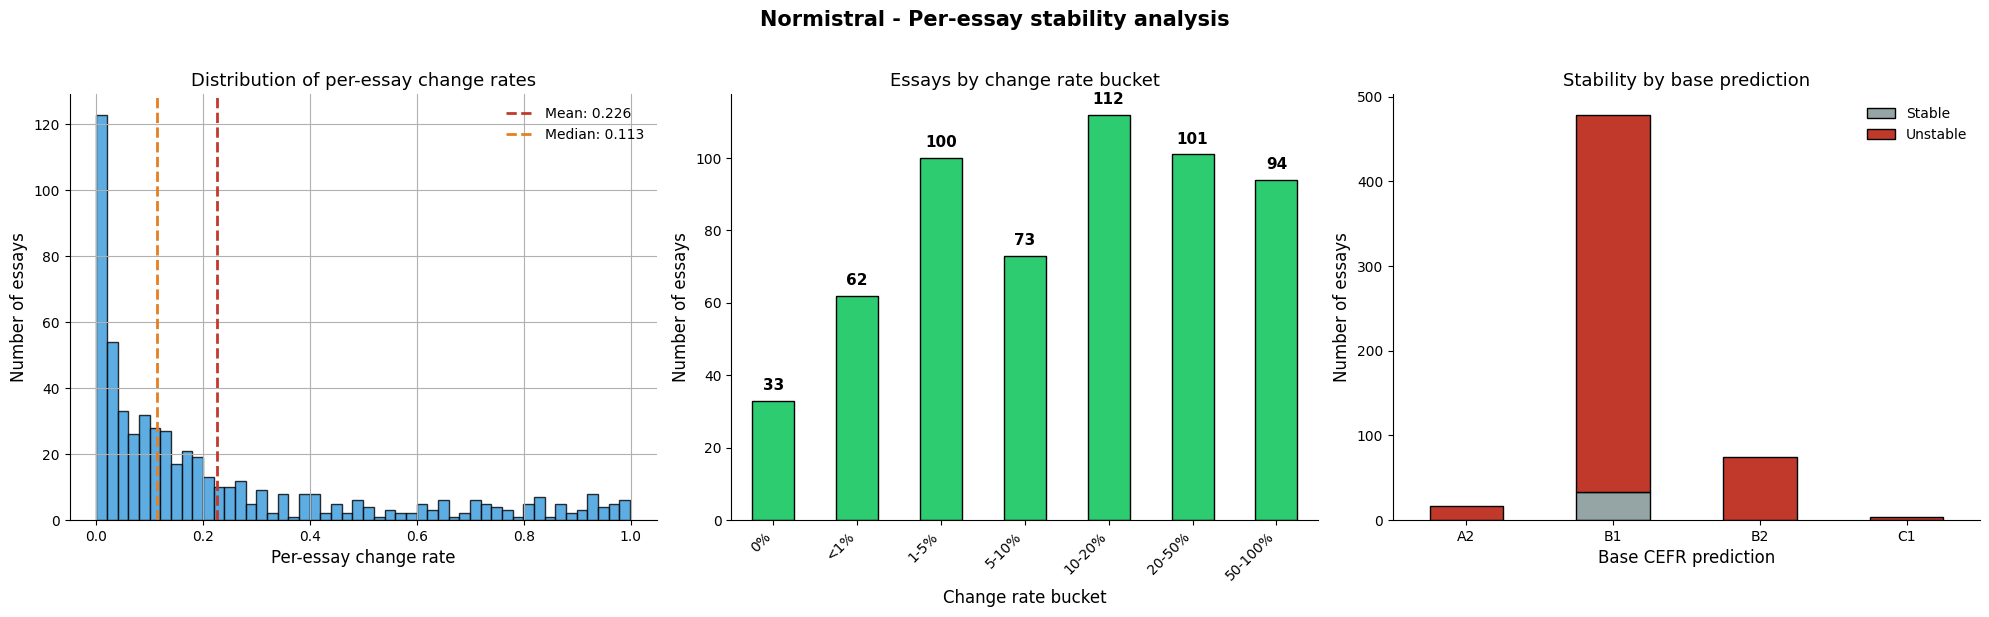


[Step 3 complete] Saved per-essay summary CSV and figure.
                  Output: essay_summary_normistral (n=575 rows)


In [ ]:
'''
Step 3 (Normistral): Per-essay stability analysis (Level 1)

This step aggregates variant-level predictions up to the essay level to characterize
how stable each essay's CEFR prediction is under demographic perturbation. Each essay
in the factorial design has up to 2,744 variants (one per demographic combination).

Note for Normistral: due to unparsed predictions, individual essays have heterogeneous
variant counts (range: 1,046 to 2,743). Per-essay change rates are computed against
each essay's actual surviving variant count, so the metric remains well-defined; but
essays with severely reduced counts produce noisier per-essay statistics. Low-count
essays are flagged in the unstable-essays printout.

The output classifies essays into:
  - Fully stable: prediction never changes under any surviving variant
  - Unstable:     prediction changes for at least one surviving variant

Per-essay statistics computed:
  - n_variants:  number of surviving variants (post-unparsed-filter)
  - change_rate: proportion of surviving variants where prediction differs from base
  - mean_D_i:    average signed difference (-3 to +3 for Normistral)
  - n_up, n_down: counts of upgrades/downgrades among surviving variants
'''

print("=" * 70)
print("NORMISTRAL - LEVEL 1: PER-ESSAY STABILITY ANALYSIS")
print("=" * 70)

# ---------------------------------------------------------------
# 3.1 Aggregate variant rows per essay
# ---------------------------------------------------------------

essay_summary_normistral = (
    df_var_normistral.groupby("essay_id")
    .agg(
        base_label=("base_label", "first"),
        base_int=("base_int", "first"),
        n_variants=("changed_vs_base", "size"),
        n_changed=("changed_vs_base", "sum"),
        change_rate=("changed_vs_base", "mean"),
        mean_D_i=("D_i", "mean"),
        n_up=("D_i", lambda s: (s > 0).sum()),
        n_down=("D_i", lambda s: (s < 0).sum()),
        n_unique_labels=("pred_label", "nunique"),
    )
    .reset_index()
)

# An essay is "stable" if all its surviving variants produce the same predicted label.
essay_summary_normistral["stable"] = essay_summary_normistral["n_unique_labels"] == 1

# ---------------------------------------------------------------
# 3.2 High-level stability counts
# ---------------------------------------------------------------

n_total = len(essay_summary_normistral)
n_stable = essay_summary_normistral["stable"].sum()
n_unstable = n_total - n_stable

print(f"\n[3.2] Stability classification")
print(f"      Total essays analyzed: {n_total}")
print(f"      Fully stable (no prediction change across any surviving variant): "
      f"{n_stable} ({100*n_stable/n_total:.1f}%)")
print(f"      Unstable (at least one variant changes the prediction): "
      f"{n_unstable} ({100*n_unstable/n_total:.1f}%)")

# ---------------------------------------------------------------
# 3.3 Distribution of per-essay change rates
# ---------------------------------------------------------------

print(f"\n[3.3] Per-essay change rate distribution")
print(f"      (proportion of surviving variants that change the prediction, per essay)")
desc = essay_summary_normistral["change_rate"].describe()
print(f"      Mean:     {desc['mean']:.4f}")
print(f"      Median:   {desc['50%']:.4f}")
print(f"      Std dev:  {desc['std']:.4f}")
print(f"      Min:      {desc['min']:.4f}")
print(f"      25th pct: {desc['25%']:.4f}")
print(f"      75th pct: {desc['75%']:.4f}")
print(f"      Max:      {desc['max']:.4f}")

# ---------------------------------------------------------------
# 3.4 Base prediction distribution
# ---------------------------------------------------------------

print(f"\n[3.4] Base prediction distribution across {n_total} retained essays")
base_dist = essay_summary_normistral["base_label"].value_counts().sort_index()
for label, count in base_dist.items():
    pct = 100 * count / n_total
    print(f"      {label}: {count:>4d} essays ({pct:.1f}%)")

# ---------------------------------------------------------------
# 3.5 Top 10 most unstable essays
# ---------------------------------------------------------------
# Each essay's variant count (n) is included to flag low-count cases where
# the change rate estimate is noisier.

print(f"\n[3.5] Top 10 most unstable essays (highest change rate)")
print(f"      base = base CEFR prediction")
print(f"      n    = surviving variants for this essay (max possible: 2743)")
print(f"      up   = number of variants that upgrade")
print(f"      down = number of variants that downgrade")

top_unstable = essay_summary_normistral.sort_values("change_rate", ascending=False).head(10)
for _, row in top_unstable.iterrows():
    flag = "  [LOW-N]" if row['n_variants'] < 1500 else ""
    print(f"      Essay {int(row['essay_id']):>4d}: base={row['base_label']}  "
          f"change_rate={row['change_rate']:.3f}  "
          f"n={int(row['n_variants']):>4d}  "
          f"up={int(row['n_up']):>4d}  down={int(row['n_down']):>4d}  "
          f"mean_D_i={row['mean_D_i']:+.3f}{flag}")

# ---------------------------------------------------------------
# 3.6 Change rate buckets
# ---------------------------------------------------------------

bins = [-0.0001, 0.0001, 0.01, 0.05, 0.10, 0.20, 0.50, 1.01]
labels_bucket = ["0%", "<1%", "1-5%", "5-10%", "10-20%", "20-50%", "50-100%"]
essay_summary_normistral["cr_bucket"] = pd.cut(
    essay_summary_normistral["change_rate"], bins=bins, labels=labels_bucket, right=False
)

print(f"\n[3.6] Change rate buckets")
print(f"      Distribution of essays by severity of instability")
bucket_counts = essay_summary_normistral["cr_bucket"].value_counts().sort_index()
for bucket, count in bucket_counts.items():
    pct = 100 * count / n_total
    print(f"      {str(bucket):>10s}:  {count:>4d} essays ({pct:5.1f}%)")

# ---------------------------------------------------------------
# 3.7 Stability rate by base prediction
# ---------------------------------------------------------------
# For Normistral, base predictions span all four levels (A2/B1/B2/C1) but are
# heavily concentrated on B1. Per-class stability rates are reported for each
# observed class, with sample sizes noted to flag classes with too few essays
# for reliable comparison.

print(f"\n[3.7] Stability rate by base prediction")
stability_by_base = (
    essay_summary_normistral.groupby("base_label")["stable"]
    .agg(["sum", "count"])
)
stability_by_base["stable_rate"] = stability_by_base["sum"] / stability_by_base["count"]
for label, row in stability_by_base.iterrows():
    n_class = int(row['count'])
    flag = "  [SMALL-N]" if n_class < 30 else ""
    print(f"      {label}: {int(row['sum']):>4d}/{n_class:<4d} stable "
          f"({100*row['stable_rate']:.1f}%) -- "
          f"{n_class - int(row['sum'])} unstable "
          f"({100*(1 - row['stable_rate']):.1f}%){flag}")

# ---------------------------------------------------------------
# 3.8 Visualizations
# ---------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: Histogram of per-essay change rates
ax = axes[0]
essay_summary_normistral["change_rate"].hist(
    bins=50, ax=ax, color="#3498db", edgecolor="black", alpha=0.8
)
ax.axvline(
    essay_summary_normistral["change_rate"].mean(), color="#c0392b",
    linestyle="--", linewidth=2,
    label=f"Mean: {essay_summary_normistral['change_rate'].mean():.3f}"
)
ax.axvline(
    essay_summary_normistral["change_rate"].median(), color="#e67e22",
    linestyle="--", linewidth=2,
    label=f"Median: {essay_summary_normistral['change_rate'].median():.3f}"
)
ax.set_xlabel("Per-essay change rate", fontsize=12)
ax.set_ylabel("Number of essays", fontsize=12)
ax.set_title("Distribution of per-essay change rates", fontsize=13)
ax.legend(fontsize=10, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel 2: Buckets
ax = axes[1]
bucket_counts.plot(kind="bar", ax=ax, color="#2ecc71", edgecolor="black")
for j, (_, n) in enumerate(bucket_counts.items()):
    ax.text(j, n + 3, str(n), ha="center", fontsize=11, fontweight="bold")
ax.set_xlabel("Change rate bucket", fontsize=12)
ax.set_ylabel("Number of essays", fontsize=12)
ax.set_title("Essays by change rate bucket", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel 3: Stability by base prediction
ax = axes[2]
stability_plot = essay_summary_normistral.groupby(["base_label", "stable"]).size().unstack(fill_value=0)

# Rename columns to strings (avoids boolean-name pandas pitfalls)
stability_plot = stability_plot.rename(columns={True: "Stable", False: "Unstable"})

# Ensure both columns exist even if one class never appears
for col in ["Stable", "Unstable"]:
    if col not in stability_plot.columns:
        stability_plot[col] = 0

# Reorder columns for consistent plotting
stability_plot = stability_plot[["Stable", "Unstable"]]

stability_plot.plot(
    kind="bar", stacked=True, ax=ax,
    color=["#95a5a6", "#c0392b"], edgecolor="black"
)
ax.set_xlabel("Base CEFR prediction", fontsize=12)
ax.set_ylabel("Number of essays", fontsize=12)
ax.set_title("Stability by base prediction", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(fontsize=10, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.suptitle(
    "Normistral - Per-essay stability analysis",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/normistral_rq2_step3_per_essay.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

# ---------------------------------------------------------------
# 3.9 Save summary
# ---------------------------------------------------------------

essay_summary_normistral.to_csv(
    "/content/drive/MyDrive/normistral_rq2_essay_summary.csv", index=False
)
print(f"\n[Step 3 complete] Saved per-essay summary CSV and figure.")
print(f"                  Output: essay_summary_normistral (n={n_total} rows)")

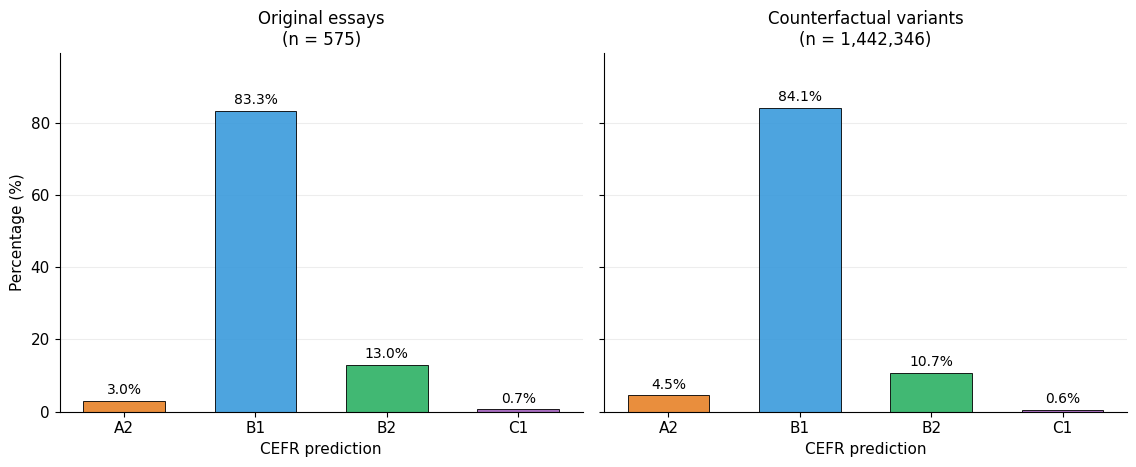

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ---------------------------------------------------------------
# Compute distributions
# ---------------------------------------------------------------

cefr_order = ["A2", "B1", "B2", "C1"]

# For Normistral, all four CEFR levels are actively predicted (unlike Llama
# and EuroLLM, which collapsed to B1/B2 only). All four levels are saturated
# in distinct colors to reflect the full prediction space being utilized.
cefr_colors = {
    "A2": "#e67e22",   # orange
    "B1": "#3498db",   # blue
    "B2": "#27ae60",   # green
    "C1": "#9b59b6",   # purple
}

base = df_normistral[df_normistral["variant_type"] == "base"]["pred_label"]
variants = df_var_normistral["pred_label"]

base_counts = base.value_counts().reindex(cefr_order, fill_value=0)
variant_counts = variants.value_counts().reindex(cefr_order, fill_value=0)

base_pct = base_counts / base_counts.sum() * 100
variant_pct = variant_counts / variant_counts.sum() * 100

# ---------------------------------------------------------------
# Plot
# ---------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), sharey=True)

plot_specs = [
    (axes[0], base_pct, base_counts, "Original essays", "Percentage of essays"),
    (axes[1], variant_pct, variant_counts, "Counterfactual variants", "Percentage of variants"),
]

ymax = max(base_pct.max(), variant_pct.max()) * 1.18

for ax, pct, counts, title, ylabel in plot_specs:
    colors = [cefr_colors[lvl] for lvl in cefr_order]
    bars = ax.bar(
        cefr_order,
        pct.values,
        color=colors,
        edgecolor="black",
        linewidth=0.7,
        width=0.62,
        alpha=0.88
    )

    for bar, p, c in zip(bars, pct.values, counts.values):
        if c > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                f"{p:.1f}%",
                ha="center",
                va="bottom",
                fontsize=10
            )

    ax.set_title(f"{title}\n(n = {int(counts.sum()):,})")
    ax.set_xlabel("CEFR prediction")
    ax.set_ylim(0, ymax)
    ax.grid(axis="y", alpha=0.22)
    ax.set_axisbelow(True)

axes[0].set_ylabel("Percentage (%)")
axes[1].set_ylabel("")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/normistral_thesis_fig_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

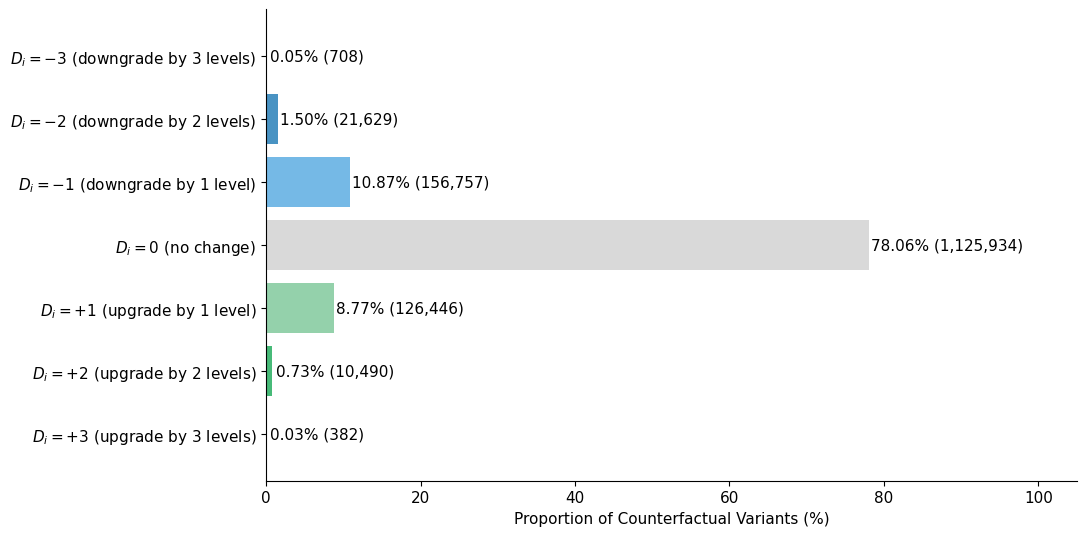

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# For Normistral, D_i can range from -3 to +3 (full ordinal CEFR scale),
# unlike Llama and EuroLLM which only produce -1, 0, +1 shifts.

labels = [
    '$D_i = -3$ (downgrade by 3 levels)',
    '$D_i = -2$ (downgrade by 2 levels)',
    '$D_i = -1$ (downgrade by 1 level)',
    '$D_i = 0$ (no change)',
    '$D_i = +1$ (upgrade by 1 level)',
    '$D_i = +2$ (upgrade by 2 levels)',
    '$D_i = +3$ (upgrade by 3 levels)',
]

n_down_3 = (df_var_normistral["D_i"] == -3).sum()
n_down_2 = (df_var_normistral["D_i"] == -2).sum()
n_down_1 = (df_var_normistral["D_i"] == -1).sum()
n_same   = (df_var_normistral["D_i"] == 0).sum()
n_up_1   = (df_var_normistral["D_i"] == 1).sum()
n_up_2   = (df_var_normistral["D_i"] == 2).sum()
n_up_3   = (df_var_normistral["D_i"] == 3).sum()
total = len(df_var_normistral)

counts = [
    int(n_down_3), int(n_down_2), int(n_down_1),
    int(n_same),
    int(n_up_1), int(n_up_2), int(n_up_3)
]
proportions = [100 * c / total for c in counts]

colors = [
    '#1a4a7a',  # dark blue (down 3)
    '#2980b9',  # medium blue (down 2)
    '#5dade2',  # light blue (down 1)
    'lightgrey',
    '#82c99c',  # light green (up 1)
    '#27ae60',  # medium green (up 2)
    '#196f3d',  # dark green (up 3)
]

fig, ax = plt.subplots(figsize=(11, 5.5))

bars = ax.barh(labels, proportions, color=colors, alpha=0.85)

for bar, prop, count in zip(bars, proportions, counts):
    x_offset = 0.5 if prop < 1 else 0.3
    ax.text(
        bar.get_width() + x_offset,
        bar.get_y() + bar.get_height() / 2,
        f'{prop:.2f}% ({count:,})',
        va='center',
        fontsize=11
    )

ax.set_xlabel('Proportion of Counterfactual Variants (%)', fontsize=11)
ax.set_xlim(0, 105)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.invert_yaxis()

plt.tight_layout()
plt.savefig('/content/normistral_exp2_direction.png', dpi=300, bbox_inches='tight')
plt.show()

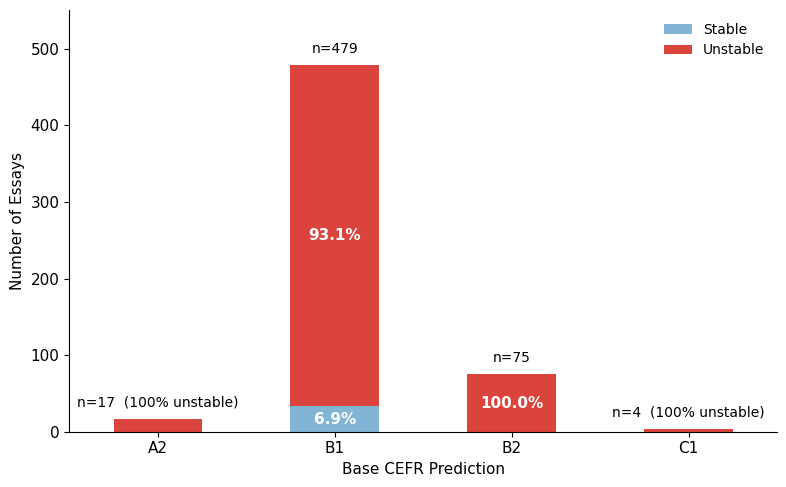

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Data — Normistral has four base prediction classes (A2, B1, B2, C1)
stability_data = {
    'Base Label': ['A2', 'A2', 'B1', 'B1', 'B2', 'B2', 'C1', 'C1'],
    'Status': ['Stable', 'Unstable', 'Stable', 'Unstable', 'Stable', 'Unstable', 'Stable', 'Unstable'],
    'Count': [0, 17, 33, 446, 0, 75, 0, 4]
}

df = pd.DataFrame(stability_data)
pivot = df.pivot(index='Base Label', columns='Status', values='Count')

# Ensure CEFR ordering on the x-axis
pivot = pivot.reindex(['A2', 'B1', 'B2', 'C1'])

fig, ax = plt.subplots(figsize=(8, 5))

pivot[['Stable', 'Unstable']].plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#74add1', '#d73027'],
    alpha=0.9,
    width=0.5
)

# Add percentage labels — only inside bars that are tall enough to be readable
MIN_BAR_HEIGHT_FOR_LABEL = 30  # only label inside if bar segment is at least this tall

for i, (base, row) in enumerate(pivot.iterrows()):
    total = row['Stable'] + row['Unstable']
    if total == 0:
        continue
    stable_pct = row['Stable'] / total * 100
    unstable_pct = row['Unstable'] / total * 100

    # Label the stable segment inside the bar only if it's tall enough
    if row['Stable'] >= MIN_BAR_HEIGHT_FOR_LABEL:
        ax.text(i, row['Stable'] / 2, f'{stable_pct:.1f}%',
                ha='center', va='center', fontsize=11, color='white', fontweight='bold')

    # Label the unstable segment inside the bar only if it's tall enough
    if row['Unstable'] >= MIN_BAR_HEIGHT_FOR_LABEL:
        ax.text(i, row['Stable'] + row['Unstable'] / 2, f'{unstable_pct:.1f}%',
                ha='center', va='center', fontsize=11, color='white', fontweight='bold')

# Add n= and percentage labels OUTSIDE the bar for small bars
for i, (base, row) in enumerate(pivot.iterrows()):
    total = row['Stable'] + row['Unstable']
    if total == 0:
        continue

    stable_pct = row['Stable'] / total * 100
    unstable_pct = row['Unstable'] / total * 100

    # Format the external label
    if total >= MIN_BAR_HEIGHT_FOR_LABEL:
        # Bar is tall enough that internal labels work; just put n= above
        external_label = f'n={int(total)}'
    else:
        # Bar is too short for internal labels; combine n= and percentage outside
        if row['Stable'] > 0:
            external_label = f'n={int(total)}\n({stable_pct:.0f}% stable, {unstable_pct:.0f}% unstable)'
        else:
            external_label = f'n={int(total)}  (100% unstable)'

    ax.text(i, total + 12, external_label,
            ha='center', va='bottom', fontsize=10, color='black')

ax.set_xlabel('Base CEFR Prediction', fontsize=11)
ax.set_ylabel('Number of Essays', fontsize=11)
ax.set_xticklabels(['A2', 'B1', 'B2', 'C1'], rotation=0)
ax.legend(fontsize=10, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Extra y-axis headroom for the external labels
ax.set_ylim(0, max(pivot.sum(axis=1)) * 1.15)

plt.tight_layout()
plt.savefig('/content/normistral_stability_by_base.png', dpi=300, bbox_inches='tight')
plt.show()

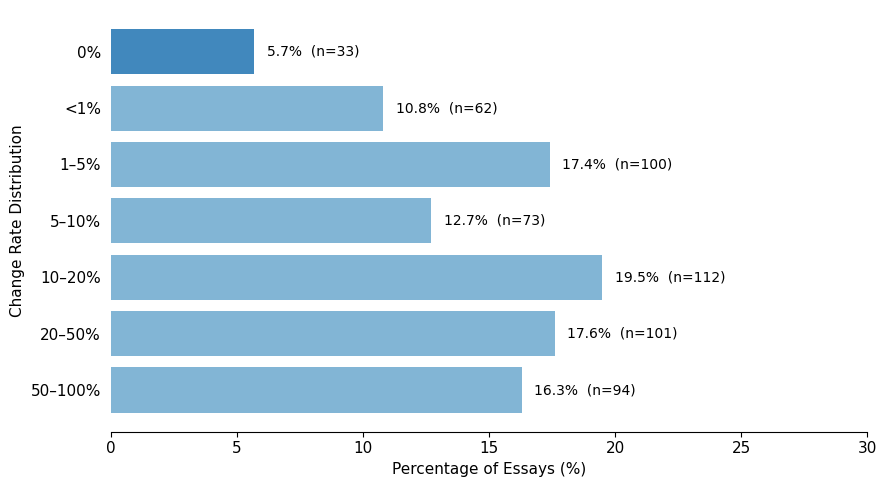

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

buckets = [
    "0%",
    "<1%",
    "1–5%",
    "5–10%",
    "10–20%",
    "20–50%",
    "50–100%"
]

# Normistral bucket counts and percentages from Step 3 output
counts = [33, 62, 100, 73, 112, 101, 94]
percentages = [5.7, 10.8, 17.4, 12.7, 19.5, 17.6, 16.3]

# Color logic: the 0% bucket (stable essays) is always dark blue to anchor it
# visually as conceptually distinct, regardless of its share. Other buckets
# use the same threshold-based scheme as Llama and EuroLLM charts.
colors = []
for i, p in enumerate(percentages):
    if i == 0:  # 0% bucket — fully stable essays
        colors.append('#2c7bb6')  # dark blue
    elif p > 20:
        colors.append('#2c7bb6')  # dark blue
    elif p > 5:
        colors.append('#74add1')  # medium blue
    else:
        colors.append('#abd9e9')  # light blue

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    buckets,
    percentages,
    color=colors,
    alpha=0.9
)

ax.invert_yaxis()

for bar, pct, count in zip(bars, percentages, counts):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%  (n={count})",
        va="center",
        fontsize=10
    )

ax.set_xlabel("Percentage of Essays (%)", fontsize=11)
ax.set_ylabel("Change Rate Distribution", fontsize=11)
ax.set_xlim(0, 30)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.tick_params(left=False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)

plt.tight_layout()
plt.savefig('/content/normistral_change_rate_buckets.png', dpi=300, bbox_inches='tight')
plt.show()

NORMISTRAL - LEVEL 2: MARGINAL MEAN PREDICTED CEFR PER DEMOGRAPHIC VALUE

Encoding: A2=1, B1=2, B2=3, C1=4
Overall mean pred_int: 2.0737
(Realized prediction range on this corpus: A2 (=1), B1 (=2), B2 (=3), C1 (=4))

gender:
  (mean predicted CEFR for each value, sorted by descending mean)
  up  mann                            mean=2.0758  (delta=+0.0021, n=721583)
  dn  kvinne                          mean=2.0716  (delta=-0.0021, n=721338)
  ------------------------------------------------------------------
  Highest predictions for: 'mann' (mean=2.0758, delta=+0.0021)
  Lowest predictions for:  'kvinne' (mean=2.0716, delta=-0.0021)
  Spread across values: 0.0042

age_group:
  (mean predicted CEFR for each value, sorted by descending mean)
  up  40–54                           mean=2.0819  (delta=+0.0082, n=361879)
  up  55 og eldre                     mean=2.0802  (delta=+0.0065, n=358167)
  up  25–39                           mean=2.0751  (delta=+0.0014, n=364226)
  dn  Under 25    

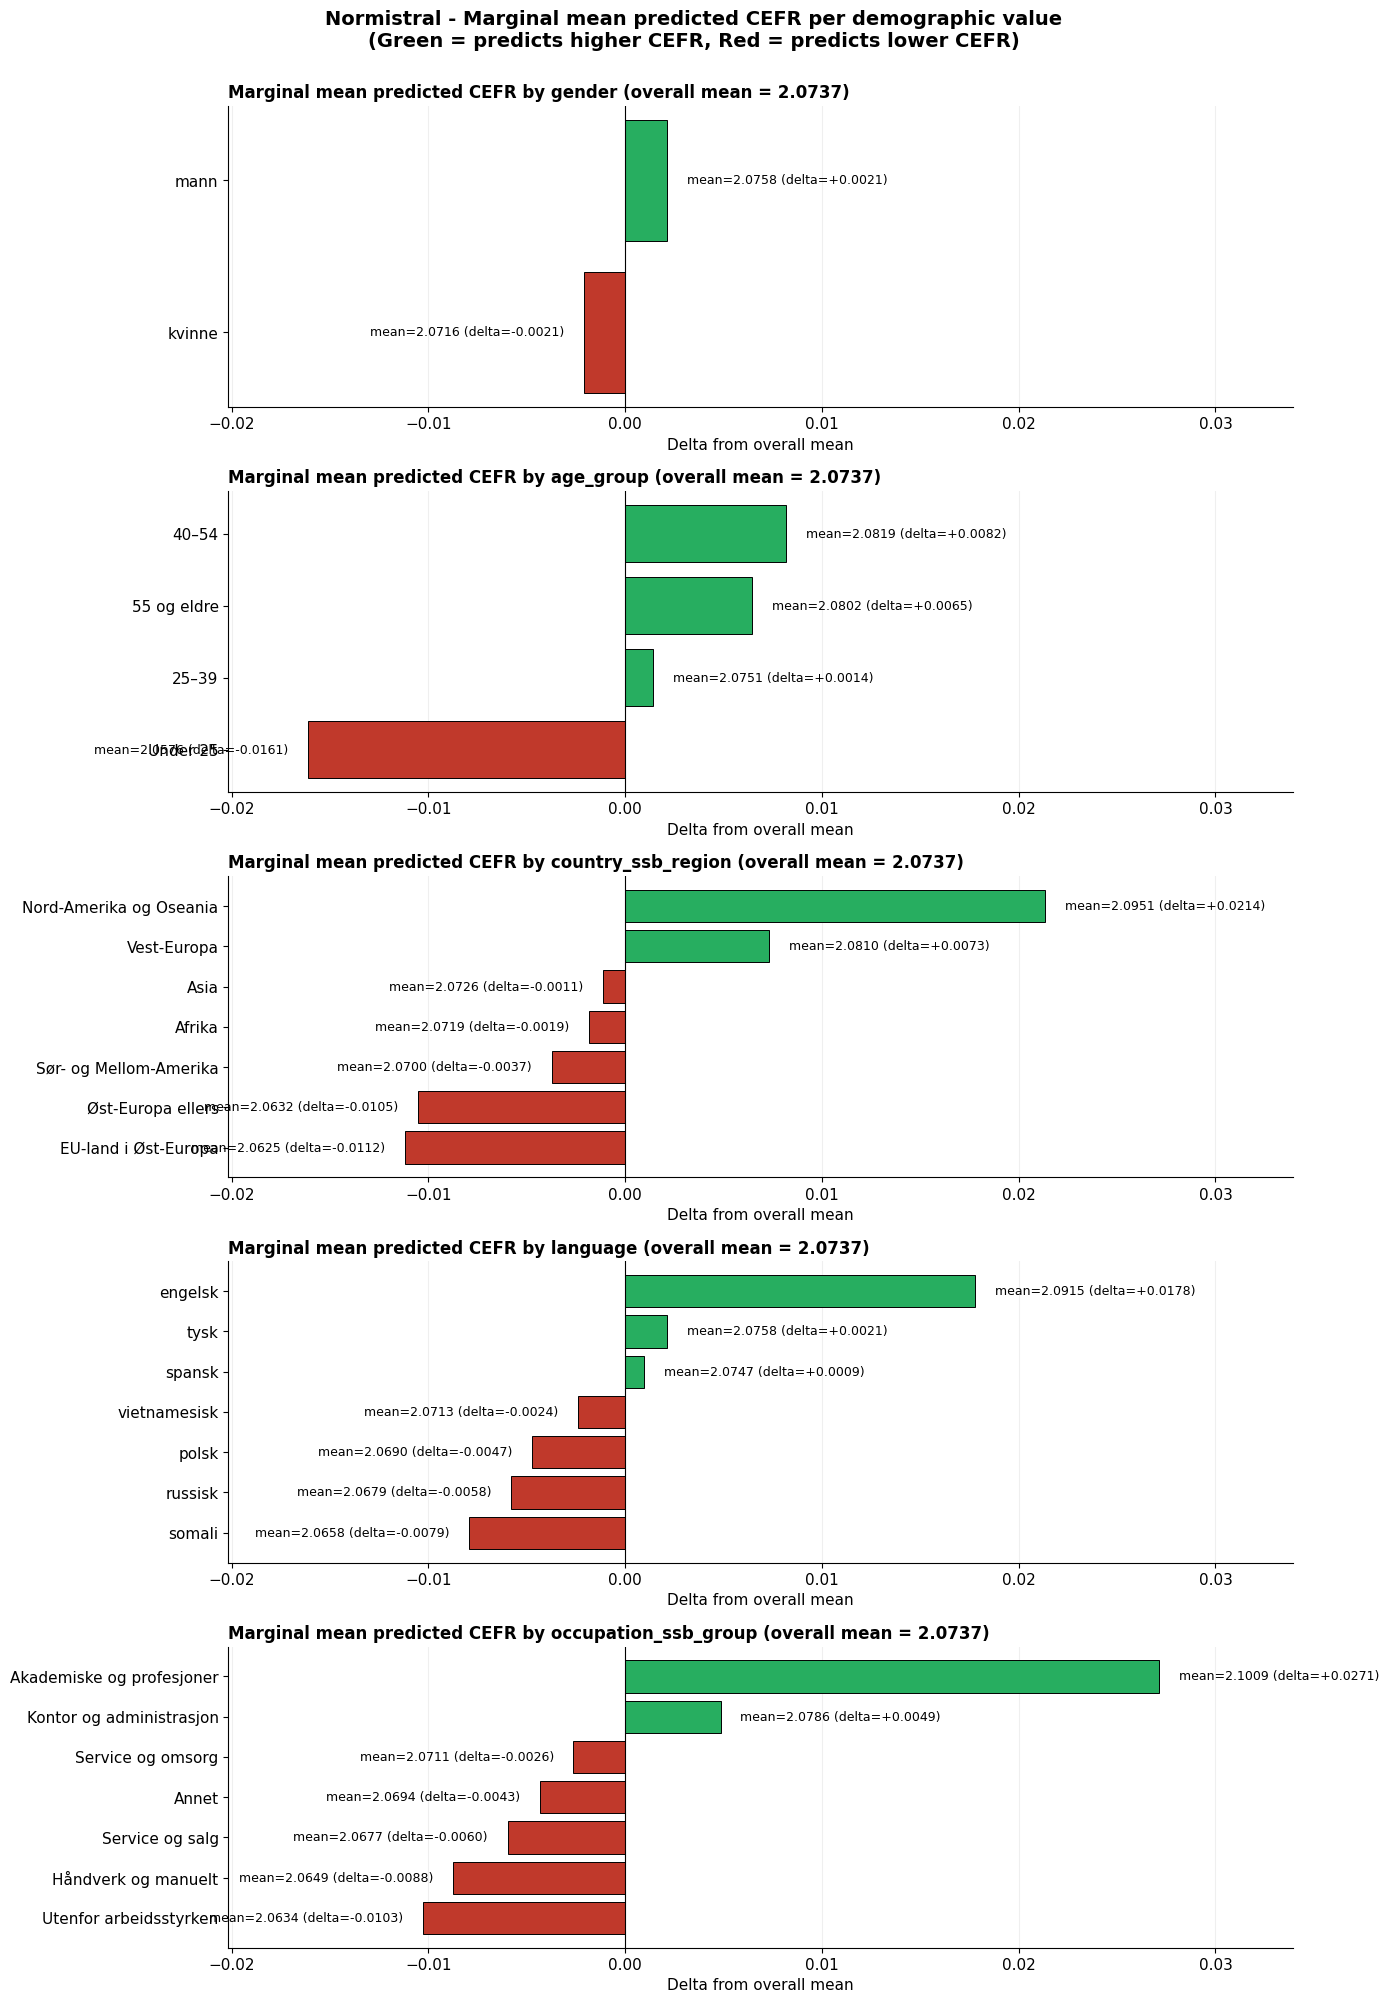


CROSS-VARIABLE SUMMARY
Overall mean predicted CEFR: 2.0737

Values with highest mean prediction per variable:
  gender                     'mann' (mean=2.0758, delta=+0.0021)
  age_group                  '40–54' (mean=2.0819, delta=+0.0082)
  country_ssb_region         'Nord-Amerika og Oseania' (mean=2.0951, delta=+0.0214)
  language                   'engelsk' (mean=2.0915, delta=+0.0178)
  occupation_ssb_group       'Akademiske og profesjoner' (mean=2.1009, delta=+0.0271)

Values with lowest mean prediction per variable:
  gender                     'kvinne' (mean=2.0716, delta=-0.0021)
  age_group                  'Under 25' (mean=2.0576, delta=-0.0161)
  country_ssb_region         'EU-land i Øst-Europa' (mean=2.0625, delta=-0.0112)
  language                   'somali' (mean=2.0658, delta=-0.0079)
  occupation_ssb_group       'Utenfor arbeidsstyrken' (mean=2.0634, delta=-0.0103)

[Step 5 complete] Saved marginal means CSV and figure.
                  Output: df_means_normistral (

In [ ]:
'''
Step 5 (Normistral): Marginal Mean Predicted CEFR per demographic value (Level 2)

For each demographic variable, this step computes the average predicted CEFR
(as an integer score) across all variants where the variable equals each value.

Encoding (unified across all models): A2=1, B1=2, B2=3, C1=4.
Unlike Llama and EuroLLM, Normistral utilizes the full four-level CEFR range,
so the realized prediction range is {1, 2, 3, 4}.

Note on metric distinction:
  - Step 4 (CR_g) measures FREQUENCY of change: how often does the prediction
    differ from the base when the variable equals g?
  - Step 5 (mean pred_int) measures CENTRAL TENDENCY of prediction: what is the
    average predicted CEFR when the variable equals g, regardless of base?

These are complementary. CR_g uses the base as reference and is direction-agnostic;
mean pred_int has no base reference and reflects absolute prediction level.

Δ here = mean pred_int for value g minus the overall mean pred_int across all
variants. A positive Δ means the model gives higher predictions when the
variable takes this value; negative Δ means lower predictions.
'''

print("=" * 70)
print("NORMISTRAL - LEVEL 2: MARGINAL MEAN PREDICTED CEFR PER DEMOGRAPHIC VALUE")
print("=" * 70)

overall_mean_normistral = df_normistral["pred_int"].mean()
print(f"\nEncoding: A2=1, B1=2, B2=3, C1=4")
print(f"Overall mean pred_int: {overall_mean_normistral:.4f}")
print(f"(Realized prediction range on this corpus: A2 (=1), B1 (=2), B2 (=3), C1 (=4))")

mean_results_normistral = []
variables = ["gender", "age_group", "country_ssb_region", "language", "occupation_ssb_group"]

# ---------------------------------------------------------------
# 5.1 Compute marginal means per demographic value
# ---------------------------------------------------------------

for var in variables:
    print(f"\n{var}:")
    print(f"  (mean predicted CEFR for each value, sorted by descending mean)")

    grp = df_normistral.groupby(var)["pred_int"].agg(["mean", "size"])
    grp = grp.sort_values("mean", ascending=False)

    for val, row in grp.iterrows():
        delta = row["mean"] - overall_mean_normistral
        if delta > 0:
            direction = "up "
        elif delta < 0:
            direction = "dn "
        else:
            direction = "== "
        print(f"  {direction} {str(val)[:30]:30s}  mean={row['mean']:.4f}  "
              f"(delta={delta:+.4f}, n={int(row['size'])})")
        mean_results_normistral.append({
            "variable": var, "value": val,
            "mean_pred_int": row["mean"],
            "delta_from_overall": delta,
            "n": int(row["size"]),
        })

    # Interpretation block
    delta_max = grp["mean"].max() - overall_mean_normistral
    delta_min = grp["mean"].min() - overall_mean_normistral
    val_max = grp["mean"].idxmax()
    val_min = grp["mean"].idxmin()
    spread = grp["mean"].max() - grp["mean"].min()

    print(f"  {'-' * 66}")
    print(f"  Highest predictions for: '{val_max}' "
          f"(mean={grp['mean'].max():.4f}, delta={delta_max:+.4f})")
    print(f"  Lowest predictions for:  '{val_min}' "
          f"(mean={grp['mean'].min():.4f}, delta={delta_min:+.4f})")
    print(f"  Spread across values: {spread:.4f}")

df_means_normistral = pd.DataFrame(mean_results_normistral)

# ---------------------------------------------------------------
# 5.2 Visualization
# ---------------------------------------------------------------

xmin = df_means_normistral["delta_from_overall"].min() * 1.25
xmax = df_means_normistral["delta_from_overall"].max() * 1.25

fig, axes = plt.subplots(len(variables), 1, figsize=(14, 20))

for idx, var in enumerate(variables):
    ax = axes[idx]
    subset = df_means_normistral[df_means_normistral["variable"] == var].sort_values(
        "mean_pred_int", ascending=True
    )

    colors = [
        "#27ae60" if d > 0 else "#c0392b" if d < 0 else "#95a5a6"
        for d in subset["delta_from_overall"]
    ]

    bars = ax.barh(
        subset["value"], subset["delta_from_overall"],
        color=colors, edgecolor="black", linewidth=0.7
    )

    for bar, delta, mean_val in zip(
        bars, subset["delta_from_overall"], subset["mean_pred_int"]
    ):
        x_pos = bar.get_width() + 0.001 if bar.get_width() >= 0 else bar.get_width() - 0.001
        ha = "left" if bar.get_width() >= 0 else "right"
        ax.text(
            x_pos, bar.get_y() + bar.get_height() / 2,
            f"mean={mean_val:.4f} (delta={delta:+.4f})",
            va="center", ha=ha, fontsize=9
        )

    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Delta from overall mean", fontsize=11)
    ax.set_title(
        f"Marginal mean predicted CEFR by {var} "
        f"(overall mean = {overall_mean_normistral:.4f})",
        fontsize=12, fontweight="bold", loc="left"
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="-", alpha=0.2)
    ax.set_axisbelow(True)

plt.suptitle(
    "Normistral - Marginal mean predicted CEFR per demographic value\n"
    "(Green = predicts higher CEFR, Red = predicts lower CEFR)",
    fontsize=14, fontweight="bold", y=1.00
)
plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/normistral_rq2_step5_marginal_means.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

# ---------------------------------------------------------------
# 5.3 Save and summarize
# ---------------------------------------------------------------

df_means_normistral.to_csv(
    "/content/drive/MyDrive/normistral_rq2_marginal_means.csv", index=False
)

print(f"\n{'=' * 70}")
print(f"CROSS-VARIABLE SUMMARY")
print(f"{'=' * 70}")
print(f"Overall mean predicted CEFR: {overall_mean_normistral:.4f}")
print(f"\nValues with highest mean prediction per variable:")
for var in variables:
    subset = df_means_normistral[df_means_normistral["variable"] == var]
    top = subset.loc[subset["mean_pred_int"].idxmax()]
    print(f"  {var:25s}  '{top['value']}' "
          f"(mean={top['mean_pred_int']:.4f}, delta={top['delta_from_overall']:+.4f})")
print(f"\nValues with lowest mean prediction per variable:")
for var in variables:
    subset = df_means_normistral[df_means_normistral["variable"] == var]
    bot = subset.loc[subset["mean_pred_int"].idxmin()]
    print(f"  {var:25s}  '{bot['value']}' "
          f"(mean={bot['mean_pred_int']:.4f}, delta={bot['delta_from_overall']:+.4f})")

print(f"\n[Step 5 complete] Saved marginal means CSV and figure.")
print(f"                  Output: df_means_normistral ({len(df_means_normistral)} rows)")

NORMISTRAL - LEVEL 2: MARGINAL CHANGE RATE (CR_g) PER DEMOGRAPHIC VALUE
Computed across 575 essays and 1,442,346 factorial variants (post-filter)

gender:
  (CR_g for each value of gender, sorted by descending change rate)
  mann                            159493/721429  CR=0.2211  ###########
  kvinne                          156919/720917  CR=0.2177  ###########
  ------------------------------------------------------------------
  Range:   0.2177 (kvinne) to 0.2211 (mann)
  Spread:  0.0034 absolute, 1.6% relative
  Most destabilizing value: 'mann' (CR=0.2211, +0.8% vs overall mean)
  Most stabilizing value:   'kvinne' (CR=0.2177, -0.8% vs overall mean)
  Interpretation: negligible spread - this variable barely affects predictions

age_group:
  (CR_g for each value of age_group, sorted by descending change rate)
  55 og eldre                      82733/358162  CR=0.2310  ############
  Under 25                         79235/358546  CR=0.2210  ###########
  40–54                      

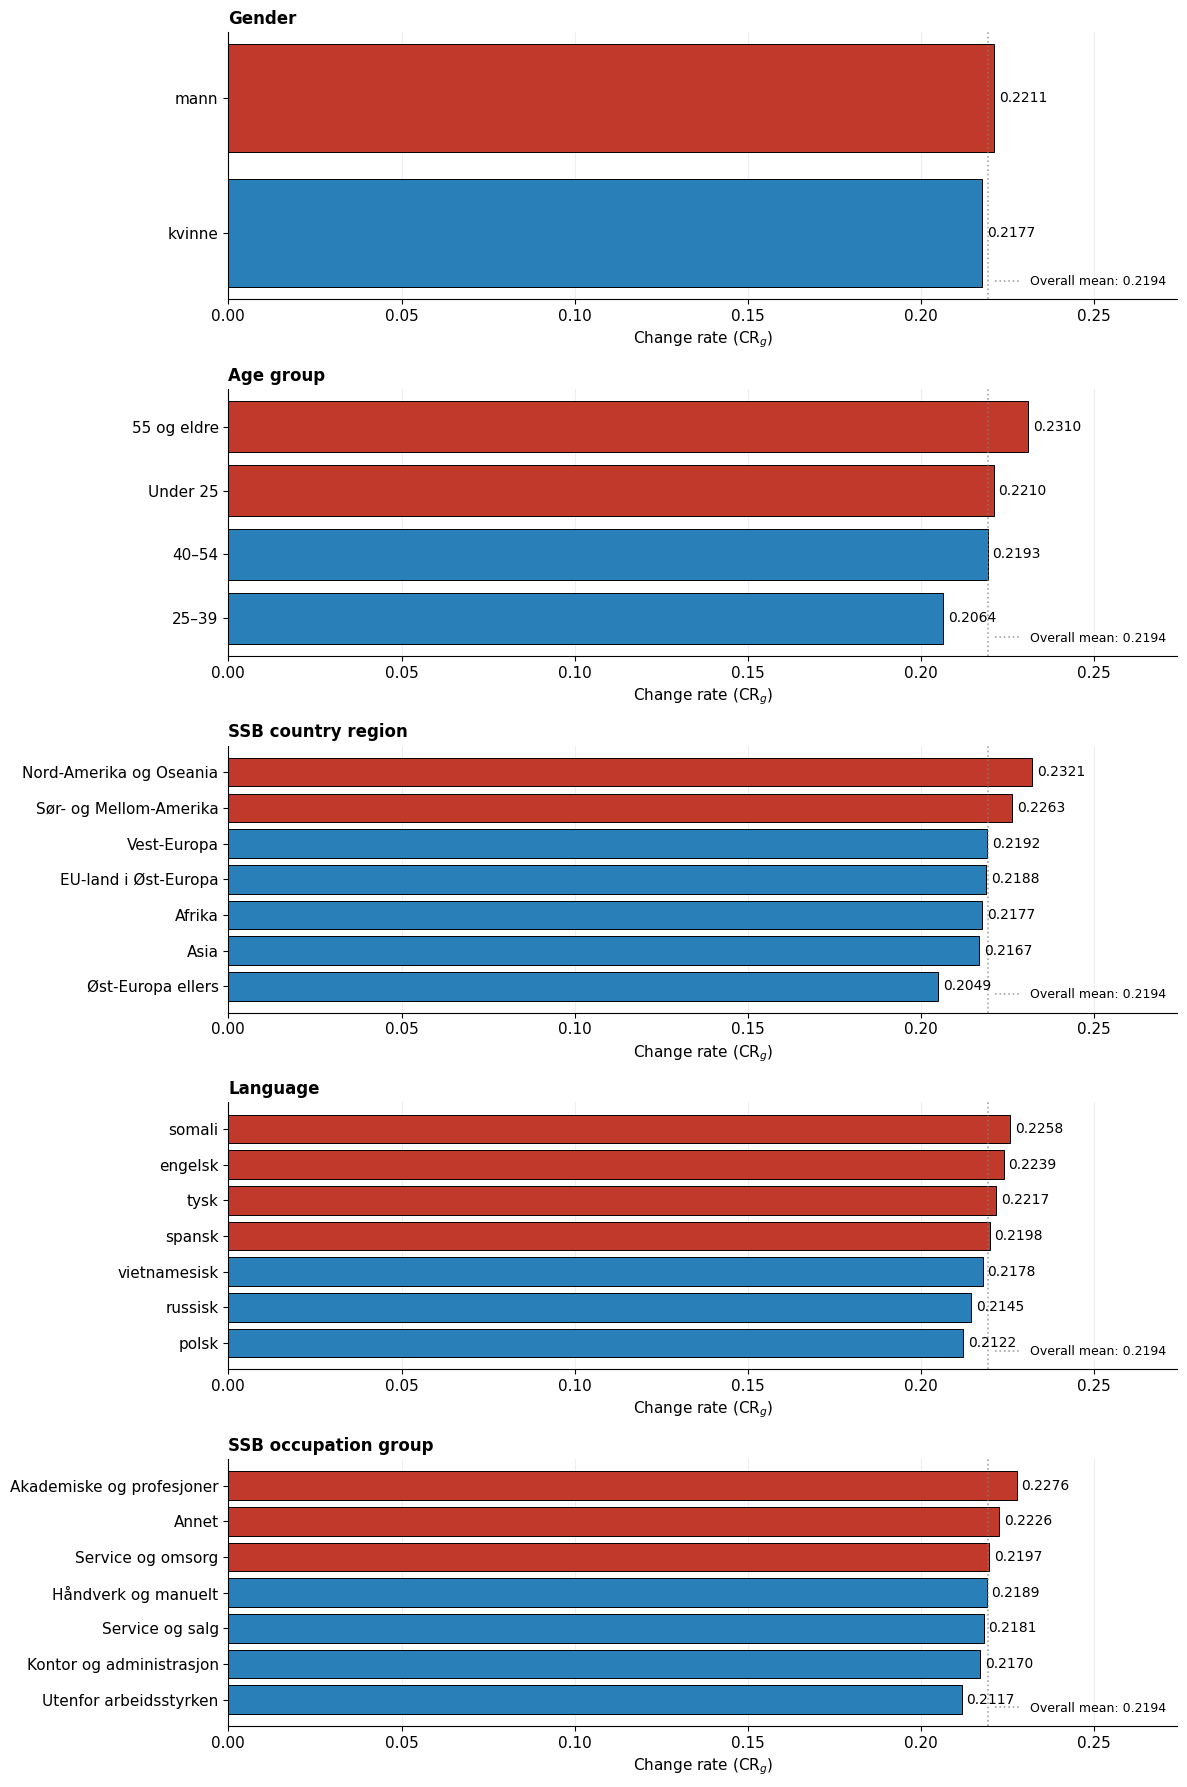


CROSS-VARIABLE SUMMARY
Overall change rate across all variants: 0.2194

Most destabilizing value per variable:
  gender                     'mann' (CR=0.2211)
  age_group                  '55 og eldre' (CR=0.2310)
  country_ssb_region         'Nord-Amerika og Oseania' (CR=0.2321)
  language                   'somali' (CR=0.2258)
  occupation_ssb_group       'Akademiske og profesjoner' (CR=0.2276)

[Step 4 complete] Saved CR_g table and figure.
                  Output: df_cr_normistral (27 rows)


In [ ]:
'''
Step 4 (Normistral): Marginal Change Rate (CR_g) per demographic value (Level 2)

For each demographic variable (gender, age, country region, language, occupation),
this step computes the change rate CR_g for every value g of that variable.

CR_g = proportion of variants with the variable equal to g where the prediction
       differs from the base.

Formally (Equation 4 in the methodology):
   CR_g = (1 / |G_g|) * sum over i in G_g of  1[y_hat_variant != y_hat_base]

This identifies which specific demographic values destabilize predictions most.
A value with a high CR_g means: when the demographic attribute takes this value,
the model's prediction changes more often relative to the base prediction.

Note: CR_g is direction-agnostic. It tells us how often predictions change but not
whether they go up or down. The Wilcoxon test (next step) addresses direction.

Note for Normistral: due to unparsed predictions, individual essays have heterogeneous
variant counts. CR_g is still well-defined since it averages over all surviving variants
for each demographic value, not over fixed denominators.
'''

print("=" * 70)
print("NORMISTRAL - LEVEL 2: MARGINAL CHANGE RATE (CR_g) PER DEMOGRAPHIC VALUE")
print(f"Computed across {df_normistral['essay_id'].nunique()} essays "
      f"and {len(df_var_normistral):,} factorial variants (post-filter)")
print("=" * 70)

cr_results_normistral = []
overall_cr_normistral = df_var_normistral["changed_vs_base"].mean()

# ---------------------------------------------------------------
# 4.1 Compute CR_g for each demographic value, with interpretation
# ---------------------------------------------------------------

variables = ["gender", "age_group", "country_ssb_region", "language", "occupation_ssb_group"]

for var in variables:
    print(f"\n{var}:")
    print(f"  (CR_g for each value of {var}, sorted by descending change rate)")

    grp = df_var_normistral.groupby(var)["changed_vs_base"].agg(["size", "sum", "mean"])
    grp.columns = ["n_variants", "n_changed", "CR_g"]
    grp = grp.sort_values("CR_g", ascending=False)

    for val, row in grp.iterrows():
        bar = "#" * int(round(row["CR_g"] * 50))
        print(f"  {str(val)[:30]:30s}  "
              f"{int(row['n_changed']):>6d}/{int(row['n_variants']):<6d}  "
              f"CR={row['CR_g']:.4f}  {bar}")
        cr_results_normistral.append({
            "variable": var, "value": val,
            "n_variants": int(row["n_variants"]),
            "n_changed": int(row["n_changed"]),
            "CR_g": row["CR_g"],
        })

    # Interpretation block
    cr_max = grp["CR_g"].max()
    cr_min = grp["CR_g"].min()
    val_max = grp["CR_g"].idxmax()
    val_min = grp["CR_g"].idxmin()
    spread = cr_max - cr_min
    relative_spread = (spread / cr_min) * 100 if cr_min > 0 else 0

    print(f"  {'-' * 66}")
    print(f"  Range:   {cr_min:.4f} ({val_min}) to {cr_max:.4f} ({val_max})")
    print(f"  Spread:  {spread:.4f} absolute, {relative_spread:.1f}% relative")
    print(f"  Most destabilizing value: '{val_max}' "
          f"(CR={cr_max:.4f}, {(cr_max/overall_cr_normistral - 1)*100:+.1f}% vs overall mean)")
    print(f"  Most stabilizing value:   '{val_min}' "
          f"(CR={cr_min:.4f}, {(cr_min/overall_cr_normistral - 1)*100:+.1f}% vs overall mean)")

    # Qualitative magnitude tag based on relative spread
    if relative_spread < 2:
        tag = "negligible spread - this variable barely affects predictions"
    elif relative_spread < 6:
        tag = "small spread - modest variation across values"
    elif relative_spread < 12:
        tag = "moderate spread - notable variation across values"
    else:
        tag = "large spread - substantial variation across values"
    print(f"  Interpretation: {tag}")

df_cr_normistral = pd.DataFrame(cr_results_normistral)

# ---------------------------------------------------------------
# 4.2 Visualization
# ---------------------------------------------------------------

# Mapping from variable code names to display labels
variable_labels = {
    "gender": "Gender",
    "age_group": "Age group",
    "country_ssb_region": "SSB country region",
    "language": "Language",
    "occupation_ssb_group": "SSB occupation group",
}

xmax = df_cr_normistral["CR_g"].max() * 1.18  # shared x-limit with headroom for labels

fig, axes = plt.subplots(len(variables), 1, figsize=(12, 18))

for idx, var in enumerate(variables):
    ax = axes[idx]
    subset = df_cr_normistral[df_cr_normistral["variable"] == var].sort_values("CR_g", ascending=True)

    # Color bars by whether they're above (red) or below (blue) the overall mean
    bar_colors = [
        "#c0392b" if cr > overall_cr_normistral else "#2980b9"
        for cr in subset["CR_g"]
    ]
    bars = ax.barh(
        subset["value"], subset["CR_g"],
        color=bar_colors, edgecolor="black", linewidth=0.7
    )

    # Value labels at the end of each bar
    for bar, cr in zip(bars, subset["CR_g"]):
        ax.text(
            bar.get_width() + xmax * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{cr:.4f}", va="center", fontsize=10
        )

    # Reference line for overall mean CR
    ax.axvline(
        overall_cr_normistral, color="gray", linestyle=":",
        linewidth=1.2, alpha=0.7,
        label=f"Overall mean: {overall_cr_normistral:.4f}"
    )

    ax.set_xlim(0, xmax)
    ax.set_xlabel("Change rate ($\\mathrm{CR}_g$)", fontsize=11)
    ax.set_title(variable_labels.get(var, var), fontsize=12, fontweight="bold", loc="left")
    ax.legend(fontsize=9, loc="lower right", frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="-", alpha=0.2)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/normistral_rq2_step4_cr_by_group.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

# ---------------------------------------------------------------
# 4.3 Save and summarize
# ---------------------------------------------------------------

df_cr_normistral.to_csv(
    "/content/drive/MyDrive/normistral_rq2_cr_by_group.csv", index=False
)

# Quick cross-variable summary
print(f"\n{'=' * 70}")
print(f"CROSS-VARIABLE SUMMARY")
print(f"{'=' * 70}")
print(f"Overall change rate across all variants: {overall_cr_normistral:.4f}")
print(f"\nMost destabilizing value per variable:")
for var in variables:
    subset = df_cr_normistral[df_cr_normistral["variable"] == var]
    top = subset.loc[subset["CR_g"].idxmax()]
    print(f"  {var:25s}  '{top['value']}' (CR={top['CR_g']:.4f})")

print(f"\n[Step 4 complete] Saved CR_g table and figure.")
print(f"                  Output: df_cr_normistral ({len(df_cr_normistral)} rows)")

NORMISTRAL - LEVEL 2: PAIRED WILCOXON SIGNED-RANK TESTS
Per-essay mean prediction when variable = g  vs.  essay's base prediction
With Benjamini-Hochberg FDR correction (alpha = 0.05)

gender:
  *** mann                          delta=-0.0356  p=0.0033  r=0.163 [small]         (n=575, n*=532)
  *** kvinne                        delta=-0.0394  p=0.0033  r=0.164 [small]         (n=575, n*=531)
  Summary: 2/2 values show significant shift after BH correction
  Strongest downgrade bias: 'kvinne' (delta=-0.0394, r=0.164, small)

age_group:
  *** 40–54                         delta=-0.0289  p=0.0009  r=0.192 [small]         (n=575, n*=515)
  *** 55 og eldre                   delta=-0.0306  p=0.0042  r=0.161 [small]         (n=575, n*=518)
  *** 25–39                         delta=-0.0358  p=0.0007  r=0.202 [small]         (n=575, n*=491)
      Under 25                      delta=-0.0545  p=0.1759  r=0.069 [negligible]    (n=575, n*=520)
  Summary: 3/4 values show significant shift after BH c

/tmp/ipykernel_23396/3603950225.py:172: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sig_count = subset["significant"].fillna(False).sum()
/tmp/ipykernel_23396/3603950225.py:176: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sig_vals = subset[subset["significant"].fillna(False)].sort_values("mean_diff")


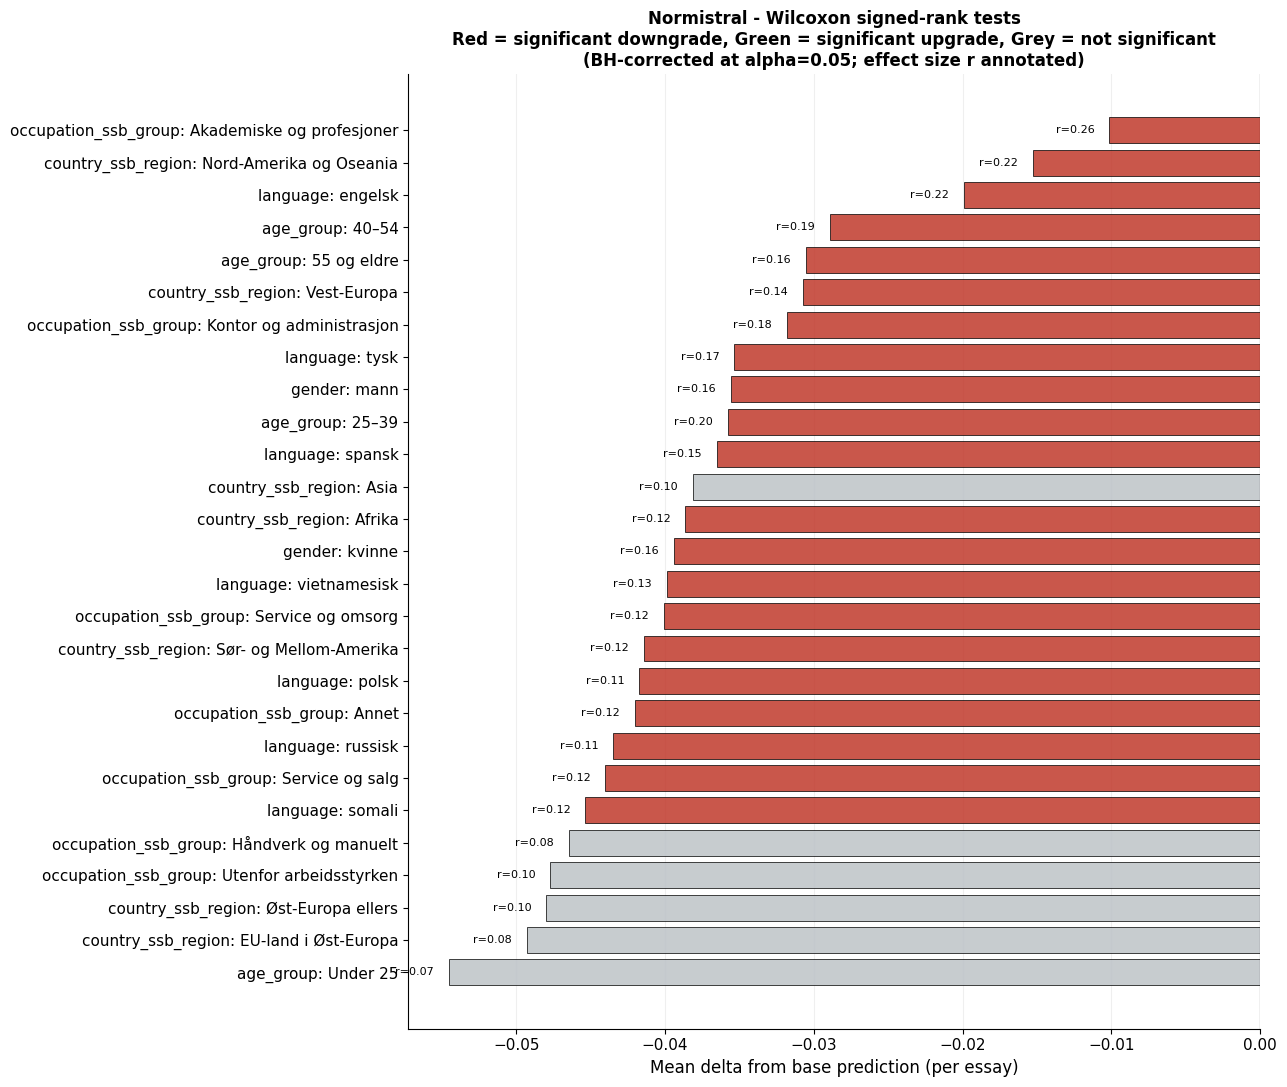


[Step 6 complete] Saved 27 test results and figure.
                  Output: df_tests_normistral


In [ ]:
'''
Step 6 (Normistral): Paired Wilcoxon Signed-Rank Tests with Benjamini-Hochberg FDR
                     correction (Level 2)

For each value g of each demographic variable, this test asks:
   Does the per-essay mean prediction when the variable equals g differ
   systematically from the essay's base prediction?

Procedure for each (variable, value) pair:
  1. For each essay, compute the mean prediction across all variants where
     the variable equals g. This per-essay aggregation respects the nested
     structure of the factorial design (variants within an essay are not
     independent observations).
  2. Compute the difference D_i = mean_when_g_i - base_i for each essay.
  3. Discard zero differences (per Hollander 1973).
  4. Run a paired Wilcoxon signed-rank test on the remaining differences,
     testing the null hypothesis that the median difference is zero.
  5. Compute the rank-biserial correlation as effect size (Equation 9).
  6. Apply Benjamini-Hochberg FDR correction across all tests within this
     model (alpha = 0.05) to control false discoveries from multiple testing.

Effect size interpretation (Cohen 1988):
   |r| < 0.10  : negligible
   |r| >= 0.10 : small
   |r| >= 0.30 : medium
   |r| >= 0.50 : large

Note for Normistral: Unlike Llama and EuroLLM (where pred_int is restricted to
{2, 3}, so D_i ranges only over {-1, 0, +1}), Normistral uses the full ordinal
range so D_i can span {-3, -2, -1, 0, +1, +2, +3}. The Wilcoxon test is therefore
non-degenerate for Normistral.

Also: due to unparsed predictions, individual essays have heterogeneous variant
counts (range: 1,046 to 2,743 surviving variants). The per-essay mean is computed
across surviving variants for each (essay, value) combination, so the test remains
well-defined; essays with severely reduced counts simply contribute slightly
noisier per-essay means.
'''

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

print("=" * 70)
print("NORMISTRAL - LEVEL 2: PAIRED WILCOXON SIGNED-RANK TESTS")
print("Per-essay mean prediction when variable = g  vs.  essay's base prediction")
print("With Benjamini-Hochberg FDR correction (alpha = 0.05)")
print("=" * 70)

all_tests_normistral = []
variables = ["gender", "age_group", "country_ssb_region", "language", "occupation_ssb_group"]

# ---------------------------------------------------------------
# 6.1 Run Wilcoxon test for each (variable, value) pair
# ---------------------------------------------------------------

for var in variables:
    values = sorted(df_normistral[var].unique())

    # For each essay and each value of this variable, compute the mean prediction
    # across all surviving variants matching that combination.
    essay_means = (
        df_normistral.groupby(["essay_id", var])["pred_int"]
        .mean()
        .unstack(fill_value=None)
    )

    # Base prediction per essay (the unperturbed reference).
    base_per_essay = (
        df_normistral[df_normistral["variant_type"] == "base"]
        .set_index("essay_id")["pred_int"]
    )

    for val in values:
        if val not in essay_means.columns:
            continue

        # Pair each essay's "mean prediction when var=g" with its base prediction.
        paired = pd.DataFrame({
            "base": base_per_essay,
            "val_mean": essay_means[val],
        }).dropna()

        diff = paired["val_mean"] - paired["base"]
        nonzero = diff[diff != 0]
        n_star = len(nonzero)

        # Skip if too few non-zero differences for a meaningful test.
        if n_star < 10:
            all_tests_normistral.append({
                "variable": var, "value": val,
                "n_essays": len(paired), "n_nonzero": n_star,
                "mean_diff": diff.mean(), "stat": None, "p_value": None,
                "r_effect": None,
            })
            continue

        # Wilcoxon signed-rank test on non-zero per-essay differences.
        stat, p = wilcoxon(nonzero)

        # Rank-biserial correlation (Kerby 2014 / Cureton 1956).
        # scipy.wilcoxon returns W = min(T+, T-) by default.
        # r = |4W / (N*(N*+1)) - 1|, equivalent to Equation 9 in the methodology.
        r = abs(4 * stat / (n_star * (n_star + 1)) - 1)

        all_tests_normistral.append({
            "variable": var, "value": val,
            "n_essays": len(paired), "n_nonzero": n_star,
            "mean_diff": diff.mean(), "stat": stat, "p_value": p,
            "r_effect": r,
        })

df_tests_normistral = pd.DataFrame(all_tests_normistral)

# ---------------------------------------------------------------
# 6.2 Apply Benjamini-Hochberg FDR correction
# ---------------------------------------------------------------

valid_mask = df_tests_normistral["p_value"].notna()
if valid_mask.sum() > 0:
    reject, pvals_corrected, _, _ = multipletests(
        df_tests_normistral.loc[valid_mask, "p_value"], method="fdr_bh", alpha=0.05
    )
    df_tests_normistral.loc[valid_mask, "p_corrected"] = pvals_corrected
    df_tests_normistral.loc[valid_mask, "significant"] = reject
else:
    df_tests_normistral["p_corrected"] = None
    df_tests_normistral["significant"] = None

# ---------------------------------------------------------------
# 6.3 Effect size interpretation per Cohen (1988)
# ---------------------------------------------------------------

def effect_label(r):
    if pd.isna(r):
        return "n/a"
    elif r >= 0.50:
        return "large"
    elif r >= 0.30:
        return "medium"
    elif r >= 0.10:
        return "small"
    else:
        return "negligible"

df_tests_normistral["effect_size"] = df_tests_normistral["r_effect"].apply(effect_label)

# ---------------------------------------------------------------
# 6.4 Display results per variable
# ---------------------------------------------------------------
# *** marks values where the test is significant after BH correction.
# Direction is shown by the sign of mean_diff:
#   negative = predictions systematically lower than base (downgrade)
#   positive = predictions systematically higher than base (upgrade)

for var in variables:
    subset = df_tests_normistral[df_tests_normistral["variable"] == var].sort_values(
        "mean_diff", ascending=False
    )
    print(f"\n{var}:")
    for _, row in subset.iterrows():
        sig = "***" if row.get("significant") else "   "
        p_str = (f"p={row['p_corrected']:.4f}"
                 if pd.notna(row.get("p_corrected")) else "p=n/a    ")
        r_str = (f"r={row['r_effect']:.3f}"
                 if pd.notna(row.get("r_effect")) else "r=n/a ")
        eff_str = f"[{row['effect_size']}]"
        print(f"  {sig} {str(row['value'])[:28]:28s}  delta={row['mean_diff']:+.4f}  "
              f"{p_str}  {r_str} {eff_str:14s}  "
              f"(n={int(row['n_essays'])}, n*={int(row['n_nonzero'])})")

    # Per-variable summary
    sig_count = subset["significant"].fillna(False).sum()
    n_total = len(subset)
    print(f"  Summary: {sig_count}/{n_total} values show significant shift after BH correction")
    if sig_count > 0:
        sig_vals = subset[subset["significant"].fillna(False)].sort_values("mean_diff")
        most_neg = sig_vals.iloc[0]
        most_pos = sig_vals.iloc[-1]
        if most_neg["mean_diff"] < 0:
            print(f"  Strongest downgrade bias: '{most_neg['value']}' "
                  f"(delta={most_neg['mean_diff']:+.4f}, "
                  f"r={most_neg['r_effect']:.3f}, {most_neg['effect_size']})")
        if most_pos["mean_diff"] > 0 and most_pos['value'] != most_neg['value']:
            print(f"  Strongest upgrade bias:   '{most_pos['value']}' "
                  f"(delta={most_pos['mean_diff']:+.4f}, "
                  f"r={most_pos['r_effect']:.3f}, {most_pos['effect_size']})")

# ---------------------------------------------------------------
# 6.5 Visualization
# ---------------------------------------------------------------
# Horizontal bar chart of mean differences across all (variable, value) pairs.
# Significant downgrades shown in red, upgrades in green, non-significant in grey.
# Each bar annotated with its effect size r.

fig, ax = plt.subplots(figsize=(13, 11))

df_plot = df_tests_normistral[df_tests_normistral["p_value"].notna()].copy()
df_plot["label"] = df_plot["variable"] + ": " + df_plot["value"].astype(str)
df_plot = df_plot.sort_values("mean_diff", ascending=True)

colors = []
for _, row in df_plot.iterrows():
    if row["significant"]:
        colors.append("#c0392b" if row["mean_diff"] < 0 else "#27ae60")
    else:
        colors.append("#bdc3c7")

bars = ax.barh(
    df_plot["label"], df_plot["mean_diff"],
    color=colors, edgecolor="black", linewidth=0.6, alpha=0.85
)

# Annotate each bar with effect size r
for bar, (_, row) in zip(bars, df_plot.iterrows()):
    width = bar.get_width()
    label_x = width + (0.001 if width >= 0 else -0.001)
    ha = "left" if width >= 0 else "right"
    ax.text(
        label_x, bar.get_y() + bar.get_height() / 2,
        f"r={row['r_effect']:.2f}",
        va="center", ha=ha, fontsize=8, color="black"
    )

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean delta from base prediction (per essay)", fontsize=12)
ax.set_title(
    "Normistral - Wilcoxon signed-rank tests\n"
    "Red = significant downgrade, Green = significant upgrade, Grey = not significant\n"
    "(BH-corrected at alpha=0.05; effect size r annotated)",
    fontsize=12, fontweight="bold"
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="-", alpha=0.2)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/normistral_rq2_step6_wilcoxon.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

# ---------------------------------------------------------------
# 6.6 Save results
# ---------------------------------------------------------------

df_tests_normistral.to_csv(
    "/content/drive/MyDrive/normistral_rq2_wilcoxon_results.csv", index=False
)
print(f"\n[Step 6 complete] Saved {len(df_tests_normistral)} test results and figure.")
print(f"                  Output: df_tests_normistral")